# 1. Perkenalan

Nama: Muhammad Raifky Leditho

Batch: 036

Objektif: 

Project ini bertujuan untuk membangun model machine learning berbasis regresi yang bisa memprediksi jumlah point (PTS) pemain NBA untuk musim depan berdasarkan statistik permainan musim lalu. model yang di kembangkan di harapkan bisa melakukan prediksi dan siap untuk menerima data pemain yang baru, sehingga bisa membantu coaching staff dan management untuk menganalisa pemain.

# 2. Import Liblary

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor




# 3. Data Loading

Load dataset sportsref_nba.csv

In [2]:
nba = pd.read_csv('sportsref_nba.csv') #load data
nba

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,5,Anthony Edwards,23,MIN,SG,79,79,36.3,9.1,20.4,...,0.8,4.9,5.7,4.5,1.2,0.6,3.2,1.9,27.6,"MVP-7,CPOY-3,AS,NBA2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,TyTy Washington Jr.,23,PHO,PG,16,0,7.4,0.9,2.8,...,0.3,0.6,0.8,1.0,0.2,0.0,0.2,0.3,2.2,NaN
496,497,Jordan McLaughlin,28,2TM,PG,46,0,6.8,0.7,1.6,...,0.1,0.5,0.7,1.1,0.3,0.0,0.3,0.4,2.1,NaN
497,498,JD Davison,22,BOS,PG,16,0,5.8,0.8,2.1,...,0.1,0.7,0.8,0.8,0.3,0.1,0.8,0.1,2.1,NaN
498,499,Chris Duarte,27,CHI,SG,17,0,4.4,0.7,1.5,...,0.3,0.9,1.2,0.5,0.0,0.0,0.1,0.4,2.1,NaN


Detail dari tiap kolom pada dataset sportsref_nba:

Dataset ini berisi data akhir dari statistik pemain NBA pada musim 2024-2025

Rk: Ranking pemain terbaik dari musim sebelum nya yaitu musim 2024-2025

Player: Berisi nama-nama pemain NBA pada tahun 2024-2025

Age: Umur pemain NBA pada tahun 2024-2025

Team: Berisi tim di mana pemain tersebut bermain di tahun 2024-2025

Pos: Berisi posisi pemain pada tahun 2024-2025 (PG: Point Guard, SG: Shooting Guard, SF: Small Forward, PF: Power Forward, C: Center)

G: Total dari gameplay pemain pada tahun 2024-2025

GS: Total dari berapa kali pemain tersebut menjadi pemain starting pada musim 2024-2025

MP: Berisi rata-rata minutes play satu musim

FG(Field Goal): Berisi rata-rata berapa kali pemain memasukan bola kecuali free throw

FGA(Field Goal Attempted): Berisi rata-rata berapa kali pemain melakukan percobaan untuk memasukan bola ke ring

FG%(Field Goal Percentage): rasio tembakan lapangan yang berhasil terhadap tembakan lapangan yang dicoba

3p: Berisi rata-rata pemain memasukan bola di luar garis 2 point

3PA: Berisi rata-rata berapa kali pemain melakukan percobaan untuk melakukan tembakan di luar garis 2 angka

3P%: Berisi persentase pemain memasukan 3 angka

2P: Berisi rata-rata pemain memasukan bola di dalam garis 2 point

2PA: Berisi rata-rata berapa kali pemain melakukan percobaan untuk melakukan tembakan dari dalam garis 2 angka

2P%: Berisi persentase pemain memasukan 2 angka

eFG%: Berisi nilai efisiensi para pemain untuk memasukan bola 

FT: Berisi berapa kali pemain memasukan tembakan free throw

FTA: Berisi rata-rata berapa kali pemain melakukan percobaan free throw

FT%: Berisi persentase berapa kali pemain memasukan free throw

ORB: Berisi rata-rata berapa kali pemain mendapatkan offensive rebound

DRB: Berisi rata-rata berapa kali pemain mendapatkan defensive rebound

TRB: Berisi rata- rata Total rebound

AST: Berisi rata-rata berapa kali pemain mendapatkan assist

STL: Berisi rata-rata berapa kali pemain mendapatkan steal atau mencuri bola 

BLK: Berisi rata-rata berapa kali pemain mendapatkan blok

TOV: Berisi rata-rata berapa kali pemain melakukan turn over 

PF: Berisi rata-rata personal foul

PTS: Berisi rata-rata point satu season

Awards: Award apa yang di dapatkan pada pemain tersebut pada musim 2024-2025




Melihat informasi pada dataset ini

In [3]:
nba.info() #melihat info pada dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      500 non-null    int64  
 1   Player  500 non-null    object 
 2   Age     500 non-null    int64  
 3   Team    500 non-null    object 
 4   Pos     500 non-null    object 
 5   G       500 non-null    int64  
 6   GS      500 non-null    int64  
 7   MP      500 non-null    float64
 8   FG      500 non-null    float64
 9   FGA     500 non-null    float64
 10  FG%     500 non-null    float64
 11  3P      500 non-null    float64
 12  3PA     500 non-null    float64
 13  3P%     482 non-null    float64
 14  2P      500 non-null    float64
 15  2PA     500 non-null    float64
 16  2P%     500 non-null    float64
 17  eFG%    500 non-null    float64
 18  FT      500 non-null    float64
 19  FTA     500 non-null    float64
 20  FT%     497 non-null    float64
 21  ORB     500 non-null    float64
 22  DR

Dataset ini memiliki 500 data, dan berisi 30 kolom, yang bertipe int64(Rk, Age, G, GS), float64(MP, FG, FGA, FG%, 3P, 3PA, 3P%, 2P, 2PA, 2P%, eFG%, FT, FTA, FT%, ORB, DRB, TRB, AST, STL, BLK, TOV, PF, PTS) dan ada 4 kolom yang bertipe object(Player, Team, Pos, Award).

Berikut adalah adalah statistik deskripsi dari dataset per column.

In [4]:
nba.describe().T # Melihat statistik deskriptive

,count,mean,std,min,25%,50%,75%,max
Rk,500.0,250.500000,144.481833,1.000,125.75000,250.5000,375.250,500.00
Age,500.0,25.998000,4.173348,19.000,23.00000,25.0000,28.000,40.00
G,500.0,50.476000,22.340179,1.000,35.00000,56.0000,70.000,82.00
GS,500.0,24.558000,26.357087,0.000,2.00000,11.5000,43.250,82.00
MP,500.0,21.390400,8.432575,4.000,14.70000,21.2000,27.925,37.70
FG,500.0,3.646600,2.251263,0.700,1.90000,3.0500,4.900,11.80
FGA,500.0,7.872000,4.674621,1.500,4.30000,6.9000,10.125,21.80
FG%,500.0,0.464072,0.083532,0.125,0.42000,0.4540,0.497,1.00
3P,500.0,1.176200,0.886829,0.000,0.50000,1.0000,1.700,4.40
3PA,500.0,3.307000,2.321843,0.000,1.50000,3.0000,4.800,11.20


Berikut adalah jumlah dari data yang terduplikasi di dataset ini

In [5]:
nba.duplicated().sum() #melihat duplicated

0

Checking unique value pada setiap kolom

In [6]:
for column in nba.columns: 
    print(f"Kolom: {column}") #looping kolom
    print(nba[column].unique()) #looping unique value
    print("-" * 30) #membuat pemisah

Kolom: Rk
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 

Melihat whitespace pada dataset di setiap kolom

In [7]:
for column in nba.columns:
    print(f"Kolom: {column}")#looping kolom
    print(nba[column].to_list()) #merubah menjadi list
    print("-" * 30) #membuat pemisah

Kolom: Rk
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

Tidak terdapat whitespace pada setiap data di setiap kolom

Melihat apakah ada whitespace di nama kolom

In [8]:
nba.columns.to_list() #melihat nama kolom 

['Rk',
 'Player',
 'Age',
 'Team',
 'Pos',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Awards']

Tidak terdapat whitespace pada nama kolom

Checking missing value pada setiap kolom

In [9]:
nba.isna().sum() #melihat missing values pada setiap kolom

Rk          0
Player      0
Age         0
Team        0
Pos         0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%         0
3P          0
3PA         0
3P%        18
2P          0
2PA         0
2P%         0
eFG%        0
FT          0
FTA         0
FT%         3
ORB         0
DRB         0
TRB         0
AST         0
STL         0
BLK         0
TOV         0
PF          0
PTS         0
Awards    447
dtype: int64

Terdapat missing value pada kolom 3P% yang berjumlah 18, FT% yang berjumlah 3, Award yang berjumlah 447.

In [10]:
nba

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,5,Anthony Edwards,23,MIN,SG,79,79,36.3,9.1,20.4,...,0.8,4.9,5.7,4.5,1.2,0.6,3.2,1.9,27.6,"MVP-7,CPOY-3,AS,NBA2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,TyTy Washington Jr.,23,PHO,PG,16,0,7.4,0.9,2.8,...,0.3,0.6,0.8,1.0,0.2,0.0,0.2,0.3,2.2,NaN
496,497,Jordan McLaughlin,28,2TM,PG,46,0,6.8,0.7,1.6,...,0.1,0.5,0.7,1.1,0.3,0.0,0.3,0.4,2.1,NaN
497,498,JD Davison,22,BOS,PG,16,0,5.8,0.8,2.1,...,0.1,0.7,0.8,0.8,0.3,0.1,0.8,0.1,2.1,NaN
498,499,Chris Duarte,27,CHI,SG,17,0,4.4,0.7,1.5,...,0.3,0.9,1.2,0.5,0.0,0.0,0.1,0.4,2.1,NaN


In [11]:
nba.info() # melihat info dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      500 non-null    int64  
 1   Player  500 non-null    object 
 2   Age     500 non-null    int64  
 3   Team    500 non-null    object 
 4   Pos     500 non-null    object 
 5   G       500 non-null    int64  
 6   GS      500 non-null    int64  
 7   MP      500 non-null    float64
 8   FG      500 non-null    float64
 9   FGA     500 non-null    float64
 10  FG%     500 non-null    float64
 11  3P      500 non-null    float64
 12  3PA     500 non-null    float64
 13  3P%     482 non-null    float64
 14  2P      500 non-null    float64
 15  2PA     500 non-null    float64
 16  2P%     500 non-null    float64
 17  eFG%    500 non-null    float64
 18  FT      500 non-null    float64
 19  FTA     500 non-null    float64
 20  FT%     497 non-null    float64
 21  ORB     500 non-null    float64
 22  DR

___________________________________________________________________________________________________________________________________________

# 4. Exploratory Data Analysis (EDA)

### EDA Question 1

1. Bagaimana distribusi Points Per Game (PTS) pemain NBA?

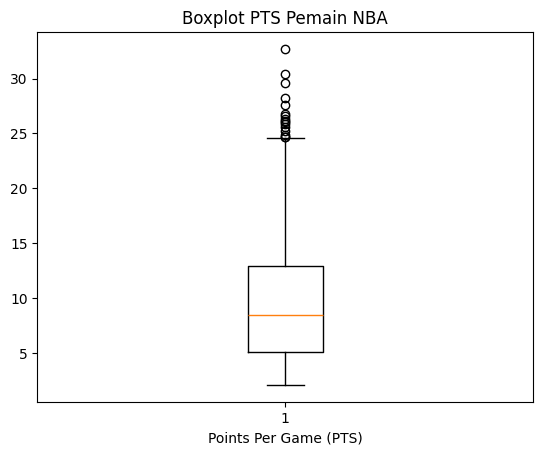

In [12]:
plt.boxplot(nba['PTS'], vert=True) #inisiasi kolom PTS
plt.xlabel('Points Per Game (PTS)') #title di bawah
plt.title('Boxplot PTS Pemain NBA') # title diatas
plt.show()

Insight:

Dari gambar di atas menunjukan bahwa distribusi dari PTS condong ke kanan atau right skewed, indikasinya adalah jarak median (garis orange) ke batas atas jauh lebih panjang daripada jarak ke batas bawah, dan juga banyak titik outliers di atas batas atas. Median dari kolom PTS adalah 8-9 PTS. dan rentang dari PTS adalah 5 sampai 13 point, dan di ambang batas upper boundary yaitu 25 point kemungkinan mereka adalah pemain superstar.

In [13]:
features = ['MP', 'FGA', '3PA', 'FTA', 'AST', 'TRB', 'FG%', 'TOV']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

MP: Spearman Corr=0.917, p-value=0.00000
FGA: Spearman Corr=0.976, p-value=0.00000
3PA: Spearman Corr=0.693, p-value=0.00000
FTA: Spearman Corr=0.832, p-value=0.00000
AST: Spearman Corr=0.745, p-value=0.00000
TRB: Spearman Corr=0.629, p-value=0.00000
FG%: Spearman Corr=0.192, p-value=0.00001
TOV: Spearman Corr=0.835, p-value=0.00000


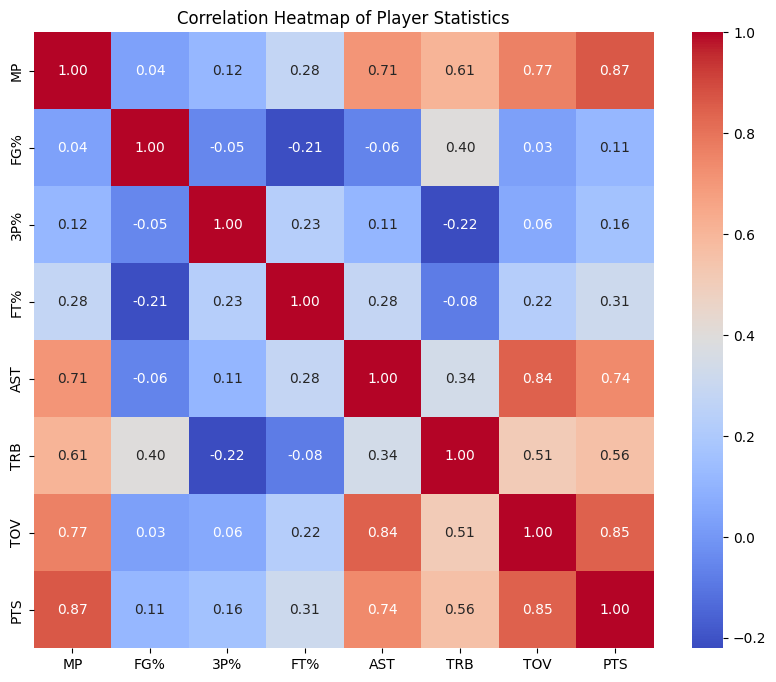

In [14]:
features = ['MP','FG%','3P%','FT%','AST','TRB','TOV','PTS']

plt.figure(figsize=(10,8))
sns.heatmap(nba[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Player Statistics')
plt.show()

___________________________________________________________________________________________________________________________________________

### EDA Question 2

Apakah Minutes Played (MP) berpengaruh terhadap PTS?

In [15]:
features = ['MP']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

MP: Spearman Corr=0.917, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara MP dan PTS adalah 0.917 yang di mana nilai tersebut mendekati 1, maka kolom MP dan kolom PTS mempunyai pengaruh yang sangat kuat.

Insight:

Pemain dengan MP (minutes play) yang tinggi cenderung memiliki PTS yang tinggi, Artinya semakin lama pemain bermain semakin besar point nya

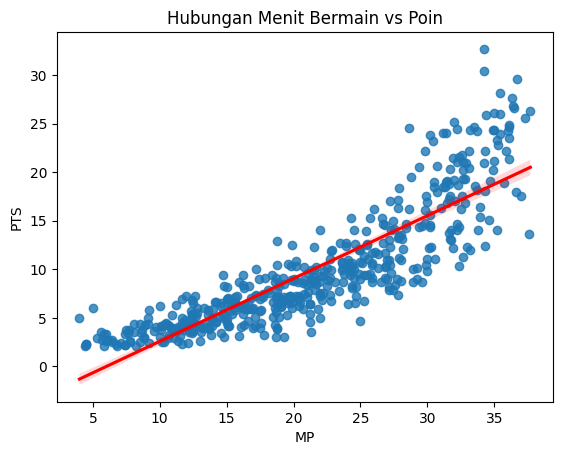

In [16]:
sns.regplot(x='MP', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan Menit Bermain vs Poin')
plt.show()

Dari grafik di atas terlihat bahwa garis merah sangat linear dengan data PTS, Yang artinya MP memiliki hubungan sangat kuat.

___________________________________________________________________________________________________________________________________________

### EDA Question 3

Bagaimana hubungan Field Goal Attempted (FGA) dengan PTS?

In [17]:
features = ['FGA']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

FGA: Spearman Corr=0.976, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara FGA dan PTS adalah 0.976 yang di mana nilai tersebut mendekati 1, maka kolom MP dan kolom PTS mempunyai pengaruh yang sangat kuat.

Insight:

Pemain dengan FGA tinggi cenderung memiliki PTS tinggi, Semakin sering pemain mencoba untuk memasukan bola maka semakin banyak pemain untuk mencetak point

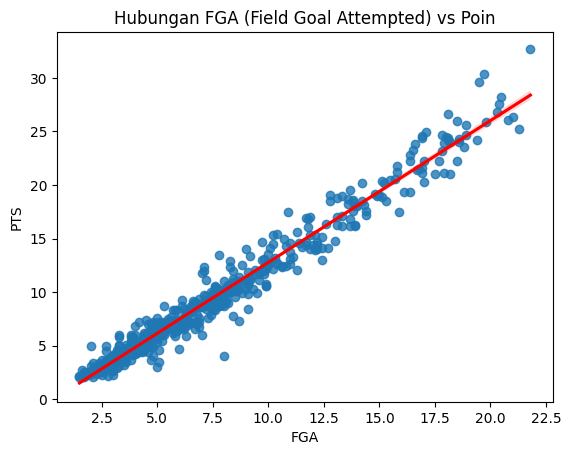

In [18]:
sns.regplot(x='FGA', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan FGA (Field Goal Attempted) vs Poin')
plt.show()

Dari grafik di atas terlihat bahwa garis merah sangat linear dengan data FGA, Yang artinya FGA memiliki hubungan yang sangat kuat.

### EDA Question 4

Apakah 3-Point Percentage (3P%) mempengaruhi PTS?

In [19]:
features = ['3P']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

3P: Spearman Corr=0.684, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara 3P dan PTS adalah 0.684 yang di mana nilai tersebut tergolong lumayan kuat karena yang di mana nilai nya tidak terlalu mendekati 1, maka dari itu 3P di kategorikan lumayan kuat, maka kolom 3P dan kolom PTS mempunyai pengaruh yang lumayan.

Insight:

Pemain dengan 3P tinggi di duga belum tentu mendapatkan PTS yang tinggi, Yang artinya semakin tinggi 3P di duga belum tentu memiliki PTS yang tinggi.

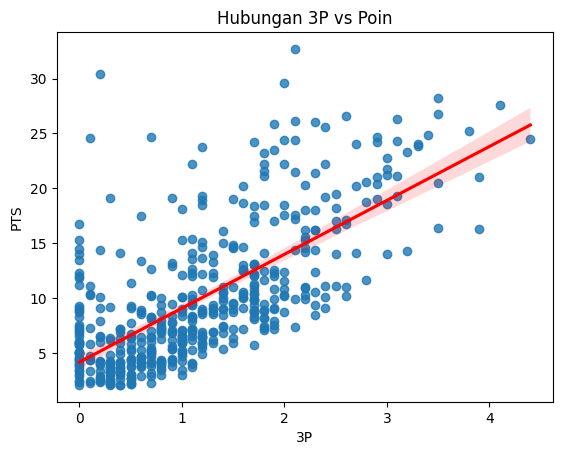

In [20]:
sns.regplot(x='3P', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan 3P vs Poin')
plt.show()

Dari grafik di atas terlihat bahwa garis merah lumayan linear dengan data PTS, Yang artinya 3P memiliki hubungan yang lumayan kuat.

### EDA Question 5

Bagaimana hubungan Assist (AST) dengan PTS?

In [21]:
features = ['AST']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

AST: Spearman Corr=0.745, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara AST dan PTS adalah 0.745 yang di mana nilai tersebut tergolong sangat kuat karena yang di mana nilai nya mendekati 1, maka dari itu AST di kategorikan sebagai hubungan yang sangat kuat, maka kolom AST dan kolom PTS mempunyai pengaruh yang sangat kuat.

Insight:

Pemain dengan AST tinggi di duga bisa mendapatkan PTS yang tinggi, Yang artinya semakin tinggi AST di duga pemain bisa mendapatkan PTS yang tinggi.

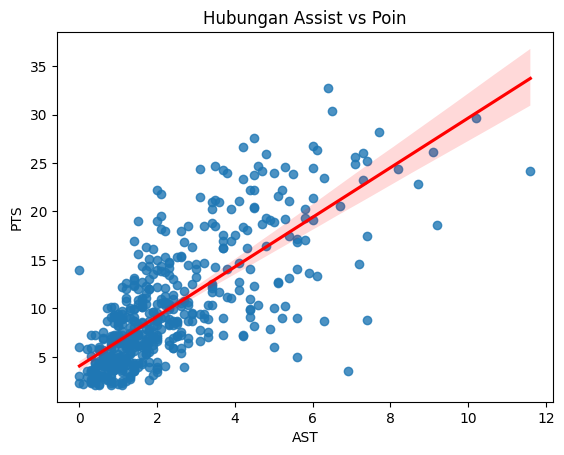

In [22]:
sns.regplot(x='AST', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan Assist vs Poin')
plt.show()

Walaupun garis merah tidak terlihat begitu linear, berkaca dengan korelasi dari spearmann yang hasil nya 0.745 yang di mana angka itu mendekati 1, maka bisa di duga bahwa AST dan PTS memiliki hubungan yang kuat.

### EDA Question 6

Apakah Age berkorelasi dengan PTS?

In [23]:
features = ['PF']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

PF: Spearman Corr=0.615, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara PF (Personal Foul) dan PTS adalah 0.615 yang di mana nilai tersebut tergolong memiliki hubungan yang lumayan, karena yang di mana nilai tersebut range nya lumayan mendekati dari 1, maka dari itu PF di kategorikan sebagai memiliki hubungan yang lumayan, maka kolom PF dan kolom PTS mempunyai pengaruh yang lumayan.

Insight:

Pemain dengan PF tinggi di duga belum tentu bisa mendapatkan PTS yang tinggi, Yang artinya semakin tinggi AST di duga pemain belum tentu mendapatkan PTS yang tinggi.

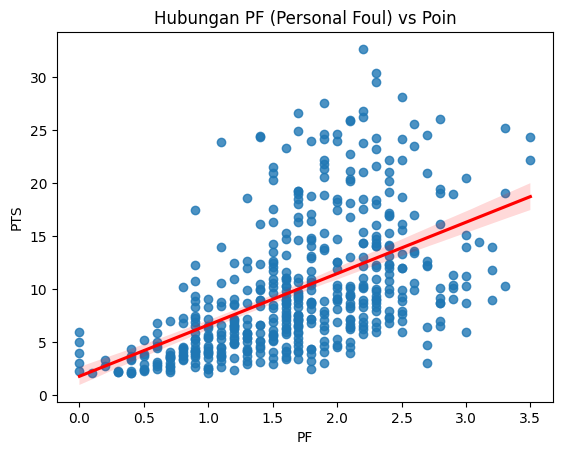

In [24]:
sns.regplot(x='PF', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan PF (Personal Foul) vs Poin')
plt.show()

Walaupun garis merah tidak terlihat begitu linear, berkaca dengan korelasi dari spearmann yang hasil nya 0.615 yang di mana angka itu lumayan mendekati 1, maka bisa di duga bahwa PF dan PTS memiliki hubungan yang lumayan kuat.

### EDA Question 7

Apakah Turnover (TOV) mempengaruhi PTS?

In [25]:
features = ['TOV']

for col in features:
    corr, p = spearmanr(nba[col], nba['PTS'])
    print(f"{col}: Spearman Corr={corr:.3f}, p-value={p:.5f}")

TOV: Spearman Corr=0.835, p-value=0.00000


Setelah melakukan korelasi menggunakan metode spearmann, korelasi antara TOV dan PTS adalah 0.835 yang di mana nilai tersebut mendekati 1, maka kolom TOV dan kolom PTS mempunyai pengaruh yang sangat kuat.

Insight:

Maksud dari TOV (Turn Over) adalah berapa kali pemain kelihangan bola saat menyerang, Statistik ini telihat seperti kekurangan dari pemain tersebut walaupun memang turn over di dunia basket itu tergolong statistik yang buruk bagi pemain saat menyerang walaupun demikian bisa di artikan pemain dengan Turnover memiliki usage rate yang tinggi biasanya pemain yang memiiki usage rate cenderung memiliki statistik turnover yang tinggi dan pemain yang usage rate nya tinggi biasanya memiliki poin yang tinggi maka dari itu korelasi dari kolom TOV dengan PTS itu tinggi, maka dari itu kolom TOV bisa di kategorikan sebagai memiliki hubungan yang kuat.

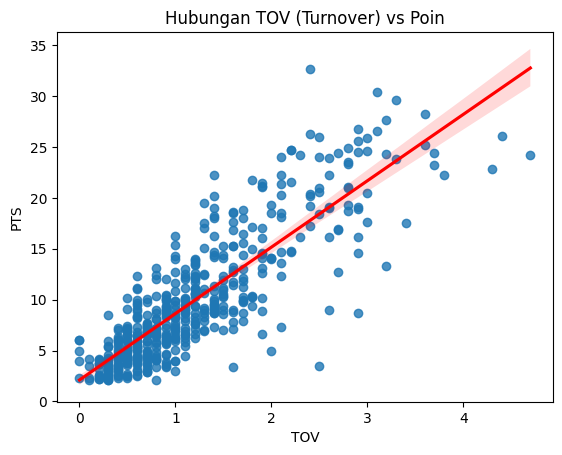

In [26]:
sns.regplot(x='TOV', y='PTS', data=nba, line_kws={"color": "red"})
plt.title('Hubungan TOV (Turnover) vs Poin')
plt.show()

Dari grafik di atas terlihat bahwa garis merah sangat linear dengan data PTS, Yang artinya TOV memiliki hubungan yang sangat kuat.

# 5. Feature Engineering

## 5.1 Checking Cardinality

In [27]:
nba

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,5,Anthony Edwards,23,MIN,SG,79,79,36.3,9.1,20.4,...,0.8,4.9,5.7,4.5,1.2,0.6,3.2,1.9,27.6,"MVP-7,CPOY-3,AS,NBA2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,TyTy Washington Jr.,23,PHO,PG,16,0,7.4,0.9,2.8,...,0.3,0.6,0.8,1.0,0.2,0.0,0.2,0.3,2.2,NaN
496,497,Jordan McLaughlin,28,2TM,PG,46,0,6.8,0.7,1.6,...,0.1,0.5,0.7,1.1,0.3,0.0,0.3,0.4,2.1,NaN
497,498,JD Davison,22,BOS,PG,16,0,5.8,0.8,2.1,...,0.1,0.7,0.8,0.8,0.3,0.1,0.8,0.1,2.1,NaN
498,499,Chris Duarte,27,CHI,SG,17,0,4.4,0.7,1.5,...,0.3,0.9,1.2,0.5,0.0,0.0,0.1,0.4,2.1,NaN


In [28]:
pd.set_option('display.max_colwidth', None)

cat_cols = list(nba.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, nba[col].nunique(), nba[col].unique()])

pd.DataFrame(columns=['nama kolom', 'jumlah nilai unique', 'nilai unique'], data=listItem)

,nama kolom,jumlah nilai unique,nilai unique
0,Player,500,"[Shai Gilgeous-Alexander, Giannis Antetokounmpo, Nikola Jokić, Luka Dončić, Anthony Edwards, Jayson Tatum, Kevin Durant, Tyrese Maxey, Cade Cunningham, Jalen Brunson, Paolo Banchero, Devin Booker, LaMelo Ball, Damian Lillard, Anthony Davis, Kyrie Irving, Zion Williamson, Stephen Curry, LeBron James, Karl-Anthony Towns, Victor Wembanyama, Franz Wagner, Trae Young, Donovan Mitchell, Cam Thomas, Tyler Herro, Joel Embiid, De'Aaron Fox, Zach LaVine, Ja Morant, James Harden, Jaylen Brown, DeMar DeRozan, Brandon Ingram, Jaren Jackson Jr., Norman Powell, Jalen Williams, Kawhi Leonard, Jamal Murray, Trey Murphy III, RJ Barrett, CJ McCollum, Jalen Green, Brandon Miller, Darius Garland, Jordan Poole, Coby White, Miles Bridges, Austin Reaves, Pascal Siakam, Kristaps Porziņģis, Scottie Barnes, Anfernee Simons, Desmond Bane, Domantas Sabonis, Alperen Şengün, John Collins, Lauri Markkanen, Jalen Johnson, Cameron Johnson, Julius Randle, Tyrese Haliburton, Evan Mobley, Shaedon Sharpe, Nikola Vučević, Collin Sexton, Michael Porter Jr., Bam Adebayo, Andrew Wiggins, OG Anunoby, Mikal Bridges, Jaden Ivey, Jimmy Butler, Dejounte Murray, Malik Monk, Immanuel Quickley, De'Andre Hunter, Bradley Beal, Deni Avdija, Keyonte George, Ivica Zubac, Derrick White, Malik Beasley, Devin Vassell, Jordan Clarkson, Paul George, Jalen Suggs, Bennedict Mathurin, Myles Turner, Christian Braun, Jonathan Kuminga, Jared McCain, Mark Williams, Kelly Oubre Jr., Chet Holmgren, Kyle Kuzma, Stephon Castle, Aaron Gordon, P.J. Washington, Quentin Grimes, ...]"
1,Team,32,"[OKC, MIL, DEN, 2TM, MIN, BOS, PHO, PHI, DET, NYK, ORL, CHO, DAL, NOP, GSW, LAL, SAS, ATL, CLE, BRK, MIA, MEM, LAC, SAC, TOR, HOU, WAS, CHI, IND, POR, UTA, 3TM]"
2,Pos,5,"[PG, PF, C, SG, SF]"
3,Awards,44,"[MVP-1,DPOY-10,CPOY-8,AS,NBA1, MVP-3,DPOY-8,AS,NBA1, MVP-2,CPOY-2,AS,NBA1, nan, MVP-7,CPOY-3,AS,NBA2, MVP-4,CPOY-10,AS,NBA1, AS, CPOY-10, MVP-7,AS,NBA3, MVP-10,CPOY-1,AS,NBA2, CPOY-10,AS, MVP-9,CPOY-5,AS,NBA2, MVP-6,CPOY-7,AS,NBA2, AS,NBA3, CPOY-4,AS, MVP-5,CPOY-9,AS,NBA1, MVP-10,AS,NBA3, DPOY-7,AS,DEF2, AS,NBA3,DEF2, CPOY-6,AS, NBA3, MVP-10,DPOY-1,AS,NBA2,DEF1, DPOY-10, 6MOY-4, DPOY-6,DEF2, 6MOY-2, ROY-7, ROY-1, 6MOY-1, 6MOY-5, DPOY-2,MIP-1,DEF1, DPOY-5,DEF1, 6MOY-7, ROY-4, ROY-2, 6MOY-3, DPOY-13,DEF2, DPOY-9,DEF2, ROY-3, DPOY-4,DEF1, 6MOY-6, ROY-6, ROY-5, DPOY-3,DEF1, 6MOY-8]"


Di sini saya akan drop kolom Player, Team dan Awards karena ketiga kolom tersebut tidak di butuhkan untuk di predict nanti dan juga cardinality nya yang tinggi juga.

In [29]:
nba = nba[['Age', 'Pos', 'MP', 'FGA', '3PA', 'FTA', 'AST', 'TRB', 'TOV', 'PTS']]

nba

,Age,Pos,MP,FGA,3PA,FTA,AST,TRB,TOV,PTS
0,26,PG,34.2,21.8,5.7,8.8,6.4,5.0,2.4,32.7
1,30,PF,34.2,19.7,0.9,10.6,6.5,11.9,3.1,30.4
2,29,C,36.7,19.5,4.7,6.4,10.2,12.7,3.3,29.6
3,25,PG,35.4,20.5,9.6,7.9,7.7,8.2,3.6,28.2
4,23,SG,36.3,20.4,10.3,6.3,4.5,5.7,3.2,27.6
...,...,...,...,...,...,...,...,...,...,...
495,23,PG,7.4,2.8,1.3,0.4,1.0,0.8,0.2,2.2
496,28,PG,6.8,1.6,1.0,0.5,1.1,0.7,0.3,2.1
497,22,PG,5.8,2.1,1.1,0.4,0.8,0.8,0.8,2.1
498,27,SG,4.4,1.5,0.9,0.5,0.5,1.2,0.1,2.1


Kolom G, GS, FG, 3P, dan FT didrop karena memiliki hubungan langsung dengan target PTS sehingga berpotensi menyebabkan data leakage.
Sementara itu, kolom seperti FG%, 3P%, 2P%, eFG%, ORB, DRB, STL, BLK, dan PF dihapus karena bersifat redundant atau memiliki relevansi rendah terhadap target, serta sudah terwakili oleh fitur lain yang digunakan

## 5.2 Spliting Features

Membagi kolom X dan y

In [30]:
X = nba.drop(['PTS'], axis = 1)
y = nba[['PTS']]
X

,Age,Pos,MP,FGA,3PA,FTA,AST,TRB,TOV
0,26,PG,34.2,21.8,5.7,8.8,6.4,5.0,2.4
1,30,PF,34.2,19.7,0.9,10.6,6.5,11.9,3.1
2,29,C,36.7,19.5,4.7,6.4,10.2,12.7,3.3
3,25,PG,35.4,20.5,9.6,7.9,7.7,8.2,3.6
4,23,SG,36.3,20.4,10.3,6.3,4.5,5.7,3.2
...,...,...,...,...,...,...,...,...,...
495,23,PG,7.4,2.8,1.3,0.4,1.0,0.8,0.2
496,28,PG,6.8,1.6,1.0,0.5,1.1,0.7,0.3
497,22,PG,5.8,2.1,1.1,0.4,0.8,0.8,0.8
498,27,SG,4.4,1.5,0.9,0.5,0.5,1.2,0.1


In [31]:
y

,PTS
0,32.7
1,30.4
2,29.6
3,28.2
4,27.6
...,...
495,2.2
496,2.1
497,2.1
498,2.1


Spliting x_train, x_test, y_train, y_test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 7)
print('Train Size', X_train.shape)
print('Test Size', X_test.shape)

Train Size (400, 9)
Test Size (100, 9)


## 5.3 Handling Outliers

In [33]:
num_cols = list(X_train.select_dtypes(exclude='object').columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness

,nama kolom,nilai skewness,distribution
0,Age,0.9,skewed
1,MP,-0.1,normal
2,FGA,0.9,skewed
3,3PA,0.7,skewed
4,FTA,1.8,skewed
5,AST,1.3,skewed
6,TRB,1.3,skewed
7,TOV,1.1,skewed


In [34]:
# Get upper, lower boundaries and percentage of outliers

column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['nama kolom'][row]
  #checking upper and lower boundary
  if skewness['distribution'][row] == 'skewed':
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,Age,43.00,8.00,0.00
1,MP,46.84,-3.52,0.00
2,FGA,28.60,-13.75,0.00
3,3PA,14.90,-8.20,0.00
4,FTA,7.60,-4.30,1.25
5,AST,9.50,-5.20,0.00
6,TRB,12.80,-5.40,0.25
7,TOV,4.60,-2.40,0.00


In [35]:
nba.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,25.9980,4.173348,19.0,23.000,25.00,28.000,40.0
MP,500.0,21.3904,8.432575,4.0,14.700,21.20,27.925,37.7
FGA,500.0,7.8720,4.674621,1.5,4.300,6.90,10.125,21.8
3PA,500.0,3.3070,2.321843,0.0,1.500,3.00,4.800,11.2
FTA,500.0,1.9146,1.659734,0.0,0.800,1.40,2.500,10.6
AST,500.0,2.3058,1.828495,0.0,1.000,1.70,3.100,11.6
TRB,500.0,3.9522,2.357492,0.0,2.375,3.40,5.000,13.9
TOV,500.0,1.2028,0.817023,0.0,0.600,1.00,1.600,4.7
PTS,500.0,9.9512,6.300477,2.1,5.100,8.45,12.925,32.7


Saya tidak handling outliers karena yang pertama presentase outliers nya tidak ekstrem dan juga banyak data yang normal, Saya ingin keep data se-real mungkin karena jika data pemain ini di capping data nya menjadi tidak realistis, data NBA ini di duga data nya sudah sangat balance karena bisa di lihat dari statistik .describe() semua data nya itu makesense secara di llihat dari min max nya dan statistik lain nya tidak ada nilai yang minus juga, jadi kita akan keep data se demikian rupa dengan tidak mengubah ubah data yang real ini.

## 5.4 Handling Missing Values

Checking missing values pada dataset training

In [36]:
X_train.isna().sum()

Age    0
Pos    0
MP     0
FGA    0
3PA    0
FTA    0
AST    0
TRB    0
TOV    0
dtype: int64

In [37]:
X_test.isna().sum()

Age    0
Pos    0
MP     0
FGA    0
3PA    0
FTA    0
AST    0
TRB    0
TOV    0
dtype: int64

In [38]:
y.isna().sum()

PTS    0
dtype: int64

Setelah di cek tidak ada missing values pada setiap kolom yang akan di train dan yang akan di test dan target itu sendiri yaitu PTS tidak terdapat missing values jadi data nya sudah bersih dan siap untuk melakukan step selanjutnya.

## 5.5 Spliting Between Numerical & Categorical

In [39]:
X_train

,Age,Pos,MP,FGA,3PA,FTA,AST,TRB,TOV
342,25,PF,17.0,7.0,3.0,2.0,5.0,4.0,0.0
359,27,SG,15.2,4.6,3.1,0.4,0.5,1.2,0.4
109,22,SF,32.2,10.1,1.3,3.6,3.8,8.2,2.0
50,29,C,28.8,13.7,6.0,4.7,2.1,6.8,1.3
452,30,C,13.1,3.6,1.6,0.6,1.4,3.1,0.9
...,...,...,...,...,...,...,...,...,...
211,27,C,22.0,6.1,0.0,2.8,0.9,8.2,1.4
67,27,C,34.3,14.3,2.8,4.2,4.3,9.6,2.1
25,25,SG,35.4,17.9,8.7,4.2,5.5,5.2,2.6
196,20,SG,22.8,9.5,5.1,0.8,2.4,2.1,1.4


di sini saya akan spliting data numerical dan categorical

In [40]:
num_columns = X_train.select_dtypes(include = np.number).columns.tolist()

cat_columns = X_train.select_dtypes(include = ['object']).columns.tolist()

print('Numeric Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numeric Columns :  ['Age', 'MP', 'FGA', '3PA', 'FTA', 'AST', 'TRB', 'TOV']
Categorical Columns :  ['Pos']


Memisahkan kolom kategori dan numerical

In [41]:
X_train_num = X_train[num_columns]
X_test_num = X_test[num_columns]

X_train_cat = X_train[cat_columns]
X_test_cat = X_test[cat_columns]

X_train_num

,Age,MP,FGA,3PA,FTA,AST,TRB,TOV
342,25,17.0,7.0,3.0,2.0,5.0,4.0,0.0
359,27,15.2,4.6,3.1,0.4,0.5,1.2,0.4
109,22,32.2,10.1,1.3,3.6,3.8,8.2,2.0
50,29,28.8,13.7,6.0,4.7,2.1,6.8,1.3
452,30,13.1,3.6,1.6,0.6,1.4,3.1,0.9
...,...,...,...,...,...,...,...,...
211,27,22.0,6.1,0.0,2.8,0.9,8.2,1.4
67,27,34.3,14.3,2.8,4.2,4.3,9.6,2.1
25,25,35.4,17.9,8.7,4.2,5.5,5.2,2.6
196,20,22.8,9.5,5.1,0.8,2.4,2.1,1.4


Terlihat ada 1 kolom yang bersifat categorical yaitu kolom Pos atau posisi di mana pemain bermain 

## 5.6 Feature Selection

In [42]:
X_train_num

,Age,MP,FGA,3PA,FTA,AST,TRB,TOV
342,25,17.0,7.0,3.0,2.0,5.0,4.0,0.0
359,27,15.2,4.6,3.1,0.4,0.5,1.2,0.4
109,22,32.2,10.1,1.3,3.6,3.8,8.2,2.0
50,29,28.8,13.7,6.0,4.7,2.1,6.8,1.3
452,30,13.1,3.6,1.6,0.6,1.4,3.1,0.9
...,...,...,...,...,...,...,...,...
211,27,22.0,6.1,0.0,2.8,0.9,8.2,1.4
67,27,34.3,14.3,2.8,4.2,4.3,9.6,2.1
25,25,35.4,17.9,8.7,4.2,5.5,5.2,2.6
196,20,22.8,9.5,5.1,0.8,2.4,2.1,1.4


ini adalah fitur numerical yang akan saya pakai untuk model inference yaitu ada Age (Umur pemain), MP (Minutes play), FGA(Field Goal Attempted), 3PA (3 Point Attempted), FTA (Free Throw Attempted), AST (Assist), TRB (), TOV (Turn Over) alasan saya menggunakan fitur ini karena fitur ini tidak menyebabkan data leakage dan kolom tersebut tidak redundant.

In [43]:
X_train_cat

,Pos
342,PF
359,SG
109,SF
50,C
452,C
...,...
211,C
67,C
25,SG
196,SG


Ini adalah fitur kolom kategori yang akan saya pakai, Alasan nya adalah posisi pemain itu juga menentukan statistik yang lain beda posisi beda statistik dan cara main

In [44]:
y

,PTS
0,32.7
1,30.4
2,29.6
3,28.2
4,27.6
...,...
495,2.2
496,2.1
497,2.1
498,2.1


Jadi ini adalah y test yang akan saya pakai.

## 5.7 Feature Scaling & Encoding

### Scaling

Di sini saya akan menggunakan RobustScaler untuk melaukan feature scaling, karena mayoritas data saya bersifat numerical, karena saya keep data se-real mungkin jadi data nya ada yang skew dan ada outliers, maka dari itu menggunakan robustScaler adalah pilihan yang cocok karena hal tersebut.

In [45]:
scaler_skew = RobustScaler()

### Encoding

saya menggunakan encoding menggunakan OneHotEncoder karena paling cocok untuk data saya yang bertipe categorical yaitu kolom Pos yang ber isi posisi dari pada pemain basket (PG, SG, SF, PF, C)

In [46]:
encoder = OneHotEncoder(handle_unknown='ignore')

Saya akan melakukan scaling dan encoder menggunakna pipeline, karena lebih simple

In [47]:
num_features = ['Age', 'MP', 'FGA', '3PA', 'FTA', 'AST', 'TRB', 'TOV']
cat_features = ['Pos']

Saya menggunakan columnTransformer untuk encoder kolom kategori

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'  # atau 'passthrough' kalau mau
)

pipe_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge())
])


# 6. Model Definition

Saya akan menguji 5 model untuk inference model saya di antara nya linear regression, ridge, lasso, randomforestregressor, gradientboostingregressor, saya memilih ke 5 model tersebut karena semua model tersebut bisa melakukan predict regression untuk detail nya ada di model evaluation.

In [49]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

# 7. Model Training

Walaupun linear regression menghasilkan MAE lebih kecil dari ridge, tetapi perbedaannya sangat kecil. Ridge Regression dipilih karena lebih stabil dalam menangani multikolinearitas antar fitur statistik pemain dan menunjukkan performa yang konsisten pada cross-validation. Dan juga linear regression juga sensitif terhadap perubahan kecil data, saya ingin mengincar ke stabilan pada model kalo saya pilih linear memang akurasinya lebih baik tetapi saya lebih mengarah ke stability nya maka dari itu saya pilih linear

Hasil Pipeline

In [50]:
final_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge())
])

final_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Age', 'MP', 'FGA', '3PA',
                                                   'FTA', 'AST', 'TRB',
                                                   'TOV']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Pos'])])),
                ('model', Ridge())])

# 8. Model Evaluation

Saya melakukan model evaluation dengan cross validation dengan metode melihat MAE, RMSE dan R2 nya

In [51]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    # train
    pipe.fit(X_train, y_train)
    
    # predict
    y_pred = pipe.predict(X_test)
    
    # evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

# tampilkan hasil
results_df = pd.DataFrame(results).sort_values(by='MAE')
results_df

,Model,MAE,RMSE,R2
0,Linear,0.631889,0.866378,0.979516
1,Ridge,0.643981,0.873465,0.979180
7,GradientBoosting,0.689478,0.970673,0.974288
6,RandomForest,0.729740,1.014256,0.971927
4,DecisionTree,0.949000,1.310076,0.953164
2,Lasso,1.173880,1.487467,0.939621
3,KNN,1.175000,1.619460,0.928430
5,SVR,1.247409,2.241130,0.862936


Hasil evaluasi:

Linear regression vs ridge regression:

Walaupun linear regression menghasilkan MAE lebih kecil dari ridge, tetapi perbedaannya sangat kecil. Ridge Regression dipilih karena lebih stabil dalam menangani multikolinearitas antar fitur statistik pemain dan menunjukkan performa yang konsisten pada cross-validation. Dan juga linear regression juga sensitif terhadap perubahan kecil data, saya ingin mengincar ke stabilan pada model kalo saya pilih linear memang akurasinya lebih baik tetapi saya lebih mengarah ke stability nya maka dari itu saya pilih ridge regression.

RandomForest:

Data saya tidak cocok untuk menggunakan model ini karena data saya sangat kecil sedangkan randomForest butuh data besar untuk generalisasi.

GradientBoosting:

Karena data sudah linear ke target PTS jadi memakai gradientBoost kurang cocok untuk data ini.

Lasso:

Terlihat dari MAE nya yang sangat buruk dari model yang lain, karena fitur berkontribusi ke PTS jadi lasso juga kurang tepat untuk di gunakan di data ini.

Decission Tree:

Terlihat dari MAE nya yang sangat buruk dan overfitting, decission tree tidak cocok untuk project ini karena metode yang di pakai regresi sehingga decission tree bekerja kurang baik

KNN: 

Dari MAE yang sangat buruk juga, sama seperti decission tree KNN tidak cocok juga untuk project ini karena metode yang di pakai regresi sehingga KNN juga bekerja kurang baik

SVR:

Dari MAE yang sangat buruk juga, model SVR tidak cocok karena dataset yang tergolong kecil menjadikan model SVR sehingga SVR kurang bekerja dengan baik untuk project regresi ini.

Checking MAPE pada model Ridge regression:

In [52]:
mape = mean_absolute_percentage_error(
    y_test.values.flatten(),
    y_pred
) * 100

print("MAPE:", mape)

MAPE: 9.022749903870432


Terlihat dari MAPE tingkat prediksi melesetnya adalah 9.02 yang di mana tingkat meleset nya tergolong kecil jadi model ini sudah siap untuk di lakukan inferensial. 

# 9. Hyperparameter Tuning

Saya akan melakukan hyperparameter tuning menggunakan GridSearchCV, Alasan menggunakan GridSearchCV:

1. Parameter tidak terlalu banyak
2. Dataset yang saya pakai tidak terlalu besar
3. Saya tidak menggunakan RandomSearch karena parameter pada dataset saya tidak besar, data saya tidak banyak.

Menggunakan hyperparameter tuning menggunakan pipeline yang berisi scaling robust dan model ridge

Melakukan Hyperparameter tuning

In [53]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Age',
                                                                          'MP',
                                                                          'FGA',
                                                                          '3PA',
                                                                          'FTA',
                                                                          'AST',
                                                                          'TRB',
                                                                          'TOV']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Pos'])])),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_absolute_error')

In [54]:
print("Best Alpha:", grid_ridge.best_params_)
print("Best CV MAE:", -grid_ridge.best_score_)

Best Alpha: {'model__alpha': 1}
Best CV MAE: 0.6545133706336503


Dari hasil hyperparameter tuning menggunakan menggunakan GridSearchCV pada model ridge regression menunjukan bahwa nilai alpha = 1 menghasilkan MAE 0.654, Dan hasil dari MAE ridge sebelum di tuning adalah 0.64, setelah tuning menjadi 0.654 pada cross validattion. yang artinya model tidak overfiting atau model tidak menghafal isi dataset. 

Terlihat dari MAPE tingkat prediksi melesetnya adalah 9.02 yang di mana tingkat meleset nya tergolong kecil jadi model ini sudah siap untuk di lakukan inferensial. 

___________________________________________________________________________________________________________________________________________

# 10 Model Saving

Melakukan model saving menggunakan joblib dan json

In [55]:
joblib.dump(final_model, 'ridge_pipeline.pkl')

metadata = {
    "numerical_features": num_features,
    "categorical_features": cat_features,
    "target": "PTS",
    "model": "Ridge Regression",
    "best_alpha": 1
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

# 11. Kesimpulan

Kesimpulan berdasarkan objektif:

Tujuan di buatnya machine learning ini adalah menganalisis faktor faktor yang mempengaruhi PTS atau poin per gamepemain nba

Tujuan dibuatnya project ini adalah untuk menganalisis faktor-faktor yang mempengaruhi Points Per Game (PTS) dari pemain NBA serta membuat model machine learning untuk memprediksi PTS berdasarkan statistik pemain NBA.

Berdasarkan hasil Exploratory Data Analysis atau (EDA) dan pemodelan yang sudah saya lakukan, dapat disimpulkan bahwa PTS sangat dipengaruhi oleh statistik ofensif pemain, seperti Minutes Played (MP), Field Goal Attempted (FGA), Assist (AST), Turnover (TOV), Assist (AST), 3 point attempted 3PA, total rebound TRB, free throw attempted FTA.

Hasil EDA menunjukkan bahwa sebagian besar fitur memiliki hubungan positif yang cukup hingga sangat kuat terhadap PTS, yang berarti semakin tinggi nilai fitur-fitur tersebut, cenderung semakin tinggi pula PTS yang dihasilkan pemain.

Dengan demikian, objective project untuk memahami hubungan statistik pemain terhadap PTS berhasil tercapai.

Kesimpulan dari EDA:

Berdasarkan analisis korelasi Spearman dan visualisasi regresi:

Minutes Played (MP) memiliki korelasi sangat kuat terhadap PTS bisa di artikan semakin lama pemain berada di lapangan, semakin besar peluang mencetak poin.

Field Goal Attempted (FGA) memiliki korelasi paling kuat terhadap PTS bisa di artikan pemain yang lebih sering melakukan percobaan tembakan cenderung memiliki PTS yang tinggi.

Assist (AST) menunjukkan hubungan yang kuat dengan PTS, bisa di artikan bahwa emain dengan keterlibatan tinggi dalam alur permainan ofensif cenderung mencetak poin lebih banyak.

3-Point (3P) memiliki hubungan yang cukup kuat bisa di artikan bahwa, Kontribusi tembakan tiga angka berpengaruh, namun tidak sekuat MP dan FGA.

Turnover (TOV) memiliki korelasi tinggi dengan PTS bisa di artikan bahwa, Hal ini menunjukkan bahwa pemain dengan usage rate tinggi cenderung memiliki PTS dan TOV yang sama-sama tinggi.

Personal Foul (PF) menunjukkan hubungan yang sedang bisa di artikan bahwa PF bukan indikator utama dalam menentukan PTS.

Secara keseluruhan, PTS lebih dipengaruhi oleh volume dan peran ofensif pemain dibandingkan efisiensi.

Overall analysist:

Secara keseluruhan, project ini berhasil menghubungkan analisis statistik permainan basket dengan pendekatan data science secara sistematis. Project ini mampu menghasilkan insight yang relevan baik dari sisi domain olahraga basket maupun dari sisi teknis analisis data, khususnya dalam memahami faktor-faktor yang memengaruhi Points Per Game (PTS) pemain NBA. Selain itu, model prediksi yang dibangun menunjukkan hasil yang selaras dengan temuan pada tahap Exploratory Data Analysis (EDA), sehingga memperkuat bahwa analisis awal yang baik berperan penting dalam mendukung performa model machine learning. Dengan alur pengerjaan yang jelas mulai dari penentuan objective, EDA, modeling, evaluation, inference, hingga conclusion, project ini telah memenuhi standar sebagai portfolio supervised learning dengan pendekatan regresi.

future improvement:

Untuk pengembangan selanjutnya, terdapat beberapa perbaikan yang dapat dilakukan guna meningkatkan performa dan kualitas analisis. Salah satunya adalah dengan menambahkan fitur berbasis efisiensi seperti FG%, 3P%, True Shooting Percentage (TS%), dan Usage Rate agar model tidak hanya bergantung pada volume statistik pemain. Selain itu, penggunaan model non-linear seperti Random Forest Regressor atau XGBoost dan Gradient Boosting dapat dipertimbangkan untuk menangkap pola hubungan yang lebih kompleks antar fitur. Pengembangan juga dapat dilakukan dengan menambahkan konteks permainan, seperti posisi pemain, pace tim, serta peran pemain sebagai starter atau bench. Dari sisi feature engineering, pembuatan fitur lanjutan seperti PTS per Minute, FGA per Minute, dan AST to Usage Ratio dapat membantu meningkatkan kemampuan prediksi model. Selanjutnya, aspek interpretabilitas model dapat ditingkatkan dengan menggunakan metode seperti SHAP atau feature importance untuk memahami kontribusi setiap fitur terhadap prediksi PTS. Terakhir, model dapat dikembangkan menjadi aplikasi interaktif berbasis Streamlit sehingga pengguna dapat memasukkan statistik pemain secara langsung dan memperoleh prediksi PTS secara real-time.